In [1]:
from polygon import RESTClient
import pandas as pd
import numpy as np
import sklearn
import scipy
import matplotlib.pyplot as plt
import collections

import datetime

from tqdm import tqdm

from constants import api_key

import time

client = RESTClient(api_key = api_key)

import pyspark

import polars as pl

In [2]:
ticker_hist_pl = pl.scan_parquet('./returns_data_2022_10_15_2024_10_14.parquet/*.parquet')

train = ticker_hist_pl.filter(pl.col("Date")<datetime.date(2024, 7, 1))
test = ticker_hist_pl.filter(pl.col("Date")>=datetime.date(2024, 7, 1))


In [3]:
tickers = pd.read_html(
    'https://en.wikipedia.org/wiki/List_of_S%26P_500_companies')[0]
print(tickers.head())

  Symbol             Security             GICS Sector  \
0    MMM                   3M             Industrials   
1    AOS          A. O. Smith             Industrials   
2    ABT  Abbott Laboratories             Health Care   
3   ABBV               AbbVie             Health Care   
4    ACN            Accenture  Information Technology   

                GICS Sub-Industry    Headquarters Location  Date added  \
0        Industrial Conglomerates    Saint Paul, Minnesota  1957-03-04   
1               Building Products     Milwaukee, Wisconsin  2017-07-26   
2           Health Care Equipment  North Chicago, Illinois  1957-03-04   
3                   Biotechnology  North Chicago, Illinois  2012-12-31   
4  IT Consulting & Other Services          Dublin, Ireland  2011-07-06   

       CIK      Founded  
0    66740         1902  
1    91142         1916  
2     1800         1888  
3  1551152  2013 (1888)  
4  1467373         1989  


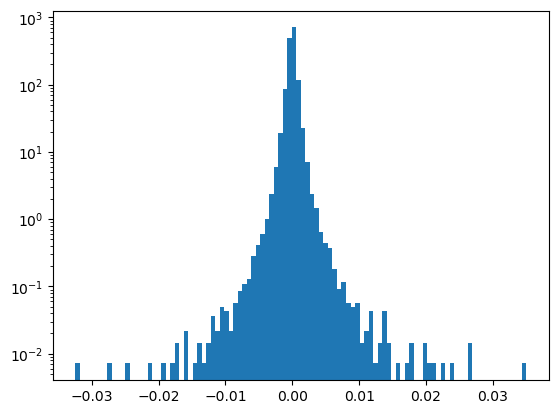

In [4]:
plt.hist(ticker_hist_pl.filter(pl.col('ticker')=='MMM').select(pl.col('logReturns')).collect(), bins = 100, density = True)
plt.yscale('log')

In [5]:
all_tickers = list(tickers['Symbol'].values) + ['VIXY']

a_params_train = {}
b_params_train = {}

a_params_test = {}
b_params_test = {}



for ticker in tqdm(all_tickers):
    a_params_train[ticker] = {}
    b_params_train[ticker] = {}

    ticker_specific_hist = train.filter(pl.col("ticker") == ticker).collect()

    dates = list(ticker_specific_hist.select("Date").unique())[0]
    
    if ticker_specific_hist.height > 0:  # Equivalent to len() in Pandas
        for date in dates:
            # Filter the DataFrame for the specific date
            ticker_hist_date = ticker_specific_hist.filter(pl.col('Date') == date)
            ticker_hist_date = ticker_hist_date.to_pandas()
            
            if len(ticker_hist_date)>0:
                ticker_hist_date = ticker_hist_date.sort_values('logReturns').reset_index(drop = True)
                ticker_hist_date.loc[:, 'cumulative_volume'] = ticker_hist_date['volume'].cumsum()/ticker_hist_date['volume'].sum()
        
                a_param = np.median(ticker_hist_date['logReturns'])
                mae = np.mean(np.abs(a_param - ticker_hist_date['logReturns']))
                
                a_params_train[ticker][date] = a_param
                b_params_train[ticker][date] = mae

for ticker in tqdm(all_tickers):
    a_params_test[ticker] = {}
    b_params_test[ticker] = {}

    ticker_specific_hist = test.filter(pl.col("ticker") == ticker).collect()

    dates = list(ticker_specific_hist.select("Date").unique())[0]
    
    if ticker_specific_hist.height > 0:  # Equivalent to len() in Pandas
        for date in dates:
            # Filter the DataFrame for the specific date
            ticker_hist_date = ticker_specific_hist.filter(pl.col('Date') == date)
            ticker_hist_date = ticker_hist_date.to_pandas()
            
            if len(ticker_hist_date)>0:
                ticker_hist_date = ticker_hist_date.sort_values('logReturns').reset_index(drop = True)
                ticker_hist_date.loc[:, 'cumulative_volume'] = ticker_hist_date['volume'].cumsum()/ticker_hist_date['volume'].sum()
        
                a_param = np.median(ticker_hist_date['logReturns'])
                mae = np.mean(np.abs(a_param - ticker_hist_date['logReturns']))
                
                a_params_test[ticker][date] = a_param
                b_params_test[ticker][date] = mae

100%|█████████████████████████████████████████| 504/504 [01:32<00:00,  5.46it/s]


In [6]:
a_params_train_df = pd.DataFrame(a_params_train).sort_index().dropna(axis=1)
a_params_test_df = pd.DataFrame(a_params_test).sort_index()[a_params_train_df.columns]
b_params_train_df = pd.DataFrame(b_params_train).sort_index()[a_params_train_df.columns]
b_params_test_df = pd.DataFrame(b_params_test).sort_index()[a_params_train_df.columns]

In [7]:
a_params_train_df.shape

(427, 486)

In [8]:
a_params_test_df.shape

(74, 486)

In [9]:
b_params_train_df.shape

(427, 486)

In [10]:
b_params_test_df.shape

(74, 486)

In [11]:
log_b_params_train_df = np.log(b_params_train_df)
log_b_params_test_df = np.log(b_params_test_df)

In [12]:
from sklearn.preprocessing import RobustScaler, StandardScaler

rs_scaler = RobustScaler()

scaled_values = rs_scaler.fit_transform(a_params_train_df.values)

scaled_a_train_df = pd.DataFrame(scaled_values, index = a_params_train_df.index, columns=a_params_train_df.columns)
scaled_a_train_df

scaled_values = rs_scaler.fit_transform(a_params_test_df.values)

scaled_a_test_df = pd.DataFrame(scaled_values, index = a_params_test_df.index, columns=a_params_test_df.columns)
scaled_a_test_df

,MMM,AOS,ABT,ABBV,ACN,ADBE,AMD,AES,AFL,A,...,WMB,WTW,WYNN,XEL,XYL,YUM,ZBRA,ZBH,ZTS,VIXY
2024-07-01,0.000000,0.0,0.000000,-0.000002,0.000000,0.000027,0.0,0.0,-0.000055,-0.000078,...,0.0,0.0,0.0,0.0,0.0,-0.000025,0.0,0.0,-0.000002,0.0
2024-07-02,0.000000,0.0,0.000000,0.000000,0.000000,0.000018,0.0,0.0,0.000000,0.000000,...,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,0.0,0.000000,0.0
2024-07-03,0.000015,0.0,0.000000,-0.000061,0.000033,0.000000,0.0,0.0,0.000000,0.000000,...,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,0.0,0.000000,0.0
2024-07-05,0.000000,0.0,0.000049,0.000023,0.000000,0.000009,0.0,0.0,0.000000,0.000000,...,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,0.0,0.000000,0.0
2024-07-08,0.000000,0.0,0.000000,0.000000,0.000000,0.000000,0.0,0.0,-0.000030,0.000000,...,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,0.0,0.000000,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2024-10-08,0.000000,0.0,0.000000,0.000000,0.000000,0.000000,0.0,0.0,0.000000,0.000000,...,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,0.0,0.000000,0.0
2024-10-09,0.000000,0.0,0.000000,0.000000,0.000000,0.000000,0.0,0.0,0.000000,0.000000,...,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,0.0,0.000000,0.0
2024-10-10,-0.000025,0.0,0.000000,0.000000,0.000000,0.000000,0.0,0.0,0.000000,0.000000,...,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,0.0,0.000000,0.0
2024-10-11,-0.000002,0.0,0.000000,0.000000,0.000000,-0.000020,0.0,0.0,0.000000,0.000000,...,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,0.0,0.000000,0.0


In [13]:
rs_scaler = RobustScaler()

scaled_values = rs_scaler.fit_transform(log_b_params_train_df.values)

scaled_b_train_df = pd.DataFrame(scaled_values, index = b_params_train_df.index, columns=b_params_train_df.columns)
scaled_b_train_df

scaled_values = rs_scaler.fit_transform(log_b_params_test_df.values)

scaled_b_test_df = pd.DataFrame(scaled_values, index = b_params_test_df.index, columns=b_params_test_df.columns)
scaled_b_test_df

,MMM,AOS,ABT,ABBV,ACN,ADBE,AMD,AES,AFL,A,...,WMB,WTW,WYNN,XEL,XYL,YUM,ZBRA,ZBH,ZTS,VIXY
2024-07-01,0.309831,-0.483533,0.222999,0.571368,0.108317,-0.130107,0.275436,1.049176,0.530710,0.584964,...,-0.712381,0.365726,0.062797,0.346459,0.800584,0.277538,0.298277,0.855062,0.500762,-1.085172
2024-07-02,-0.743592,-0.291268,-0.923237,0.699597,-0.441973,-0.045785,0.004816,0.526059,-0.423094,-0.346315,...,-0.766883,-0.577964,-0.153562,-0.280773,-0.182379,-0.245957,-0.173685,-0.576713,0.312542,-1.455763
2024-07-03,0.254302,1.090989,0.782226,1.328791,-0.006698,0.915686,0.202320,0.973457,1.211659,1.121677,...,0.668676,0.418271,0.791140,0.966656,0.712365,0.669105,0.394384,0.507840,1.132534,-1.339035
2024-07-05,-0.734079,-0.163440,-0.612648,-0.001913,0.129301,-0.508112,0.396678,-0.213441,-0.537568,-0.539410,...,-0.661189,-0.215743,-0.599294,-0.160410,-0.359729,-1.140407,-0.843011,-0.565406,-1.164404,-1.125026
2024-07-08,-0.509432,-1.269430,-0.212279,-0.149684,-0.386593,0.282091,0.102847,-0.921728,-0.343445,-0.805455,...,-0.969820,-0.596616,-0.628045,-0.339704,-0.949734,-0.532072,-1.004046,-0.085736,-0.928839,-1.470645
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2024-10-08,-0.866509,0.419523,0.332936,-1.031604,-0.975437,-0.526142,-0.916676,-0.416443,-0.669800,-0.727252,...,0.577171,-0.051134,1.312509,-0.219294,-0.579907,-0.294356,-0.715343,-0.301594,0.047153,-0.233800
2024-10-09,-0.686326,-1.266950,-0.300301,-0.532172,-0.462531,-1.635507,-0.865789,-0.224577,0.659975,-1.278619,...,-0.562721,0.124019,0.281609,-0.552619,-0.565797,-1.488199,-0.437767,-0.279204,-1.316326,-0.869864
2024-10-10,-0.876658,-1.184676,-0.653925,-0.899342,0.136421,-0.140913,-0.004816,0.101423,0.162642,-1.154509,...,-0.163770,0.495981,0.129008,-0.657008,-0.429607,0.490768,0.699602,-0.433631,-0.465136,-0.173169
2024-10-11,-1.301668,2.938935,-0.468877,-0.933148,-1.017980,-0.928938,-0.942213,-0.399676,-0.366461,-0.355963,...,-0.017387,0.304282,0.035987,-1.044039,-0.938983,-0.886467,-0.425334,-0.694400,-0.368307,-0.818264


In [14]:
one_shifted = scaled_a_train_df.shift(-1)
one_shifted.columns = [f'{col_name}_shift1' for col_name in scaled_a_train_df.columns]
one_shifted = pd.DataFrame(one_shifted.values.flatten())

two_shifted = scaled_a_train_df.shift(-2)
two_shifted.columns = [f'{col_name}_shift2' for col_name in scaled_a_train_df.columns]
two_shifted = pd.DataFrame(two_shifted.values.flatten())

three_shifted = scaled_a_train_df.shift(-3)
three_shifted.columns = [f'{col_name}_shift3' for col_name in scaled_a_train_df.columns]
three_shifted = pd.DataFrame(three_shifted.values.flatten())

four_shifted = scaled_a_train_df.shift(-4)
four_shifted.columns = [f'{col_name}_shift4' for col_name in scaled_a_train_df.columns]
four_shifted = pd.DataFrame(four_shifted.values.flatten())

five_shifted = scaled_a_train_df.shift(-5)
five_shifted.columns = [f'{col_name}_shift5' for col_name in scaled_a_train_df.columns]
five_shifted = pd.DataFrame(five_shifted.values.flatten())

collapsed_df = pd.DataFrame(scaled_a_train_df.values.flatten())

train_a = pd.concat([collapsed_df, one_shifted, two_shifted, three_shifted, four_shifted, five_shifted], axis=1)



one_shifted = scaled_a_test_df.shift(-1)
one_shifted.columns = [f'{col_name}_shift1' for col_name in scaled_a_test_df.columns]
one_shifted = pd.DataFrame(one_shifted.values.flatten())

two_shifted = scaled_a_test_df.shift(-2)
two_shifted.columns = [f'{col_name}_shift2' for col_name in scaled_a_test_df.columns]
two_shifted = pd.DataFrame(two_shifted.values.flatten())

three_shifted = scaled_a_test_df.shift(-3)
three_shifted.columns = [f'{col_name}_shift3' for col_name in scaled_a_test_df.columns]
three_shifted = pd.DataFrame(three_shifted.values.flatten())

four_shifted = scaled_a_test_df.shift(-4)
four_shifted.columns = [f'{col_name}_shift4' for col_name in scaled_a_test_df.columns]
four_shifted = pd.DataFrame(four_shifted.values.flatten())

five_shifted = scaled_a_test_df.shift(-5)
five_shifted.columns = [f'{col_name}_shift5' for col_name in scaled_a_test_df.columns]
five_shifted = pd.DataFrame(five_shifted.values.flatten())

collapsed_df = pd.DataFrame(scaled_a_test_df.values.flatten())

test_a = pd.concat([collapsed_df, one_shifted, two_shifted, three_shifted, four_shifted, five_shifted], axis=1)

In [15]:
one_shifted = scaled_b_train_df.shift(-1)
one_shifted.columns = [f'{col_name}_shift1' for col_name in scaled_b_train_df.columns]
one_shifted = pd.DataFrame(one_shifted.values.flatten())

two_shifted = scaled_b_train_df.shift(-2)
two_shifted.columns = [f'{col_name}_shift2' for col_name in scaled_b_train_df.columns]
two_shifted = pd.DataFrame(two_shifted.values.flatten())

three_shifted = scaled_b_train_df.shift(-3)
three_shifted.columns = [f'{col_name}_shift3' for col_name in scaled_b_train_df.columns]
three_shifted = pd.DataFrame(three_shifted.values.flatten())

four_shifted = scaled_b_train_df.shift(-4)
four_shifted.columns = [f'{col_name}_shift4' for col_name in scaled_b_train_df.columns]
four_shifted = pd.DataFrame(four_shifted.values.flatten())

five_shifted = scaled_b_train_df.shift(-5)
five_shifted.columns = [f'{col_name}_shift5' for col_name in scaled_b_train_df.columns]
five_shifted = pd.DataFrame(five_shifted.values.flatten())

collapsed_df = pd.DataFrame(scaled_b_train_df.values.flatten())

train_b = pd.concat([collapsed_df, one_shifted, two_shifted, three_shifted, four_shifted, five_shifted], axis=1)



one_shifted = scaled_b_test_df.shift(-1)
one_shifted.columns = [f'{col_name}_shift1' for col_name in scaled_b_test_df.columns]
one_shifted = pd.DataFrame(one_shifted.values.flatten())

two_shifted = scaled_b_test_df.shift(-2)
two_shifted.columns = [f'{col_name}_shift2' for col_name in scaled_b_test_df.columns]
two_shifted = pd.DataFrame(two_shifted.values.flatten())

three_shifted = scaled_b_test_df.shift(-3)
three_shifted.columns = [f'{col_name}_shift3' for col_name in scaled_b_test_df.columns]
three_shifted = pd.DataFrame(three_shifted.values.flatten())

four_shifted = scaled_b_test_df.shift(-4)
four_shifted.columns = [f'{col_name}_shift4' for col_name in scaled_b_test_df.columns]
four_shifted = pd.DataFrame(four_shifted.values.flatten())

five_shifted = scaled_b_test_df.shift(-5)
five_shifted.columns = [f'{col_name}_shift5' for col_name in scaled_b_test_df.columns]
five_shifted = pd.DataFrame(five_shifted.values.flatten())

collapsed_df = pd.DataFrame(scaled_b_test_df.values.flatten())

test_b = pd.concat([collapsed_df, one_shifted, two_shifted, three_shifted, four_shifted, five_shifted], axis=1)

In [16]:
train_a.columns = [f'{i}_shift_a' for i in range(6)]
test_a.columns = [f'{i}_shift_a' for i in range(6)]

train_b.columns = [f'{i}_shift_b' for i in range(6)]
test_b.columns = [f'{i}_shift_b' for i in range(6)]



In [21]:
scipy.stats.pearsonr(train_a.dropna()['0_shift_a'], train_a.dropna()['1_shift_a'])

PearsonRResult(statistic=np.float64(0.05895768792128107), pvalue=np.float64(2.523688288116755e-157))

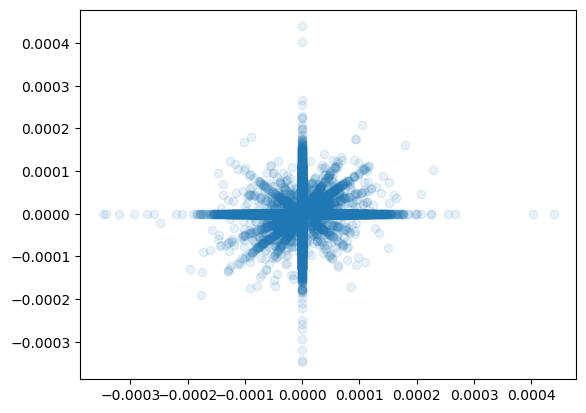

In [18]:
plt.scatter(train_a.dropna()['0_shift_a'], train_a.dropna()['1_shift_a'], alpha = 0.1)

In [22]:
scipy.stats.spearmanr(train_b.dropna()['0_shift_b'], train_b.dropna()['1_shift_b'])

SignificanceResult(statistic=np.float64(0.6318028912489311), pvalue=np.float64(0.0))

In [20]:
train_ab = pd.concat([train_a, train_b], axis=1)
test_ab = pd.concat([test_a, test_b], axis=1)


ValueError: Contour levels must be increasing

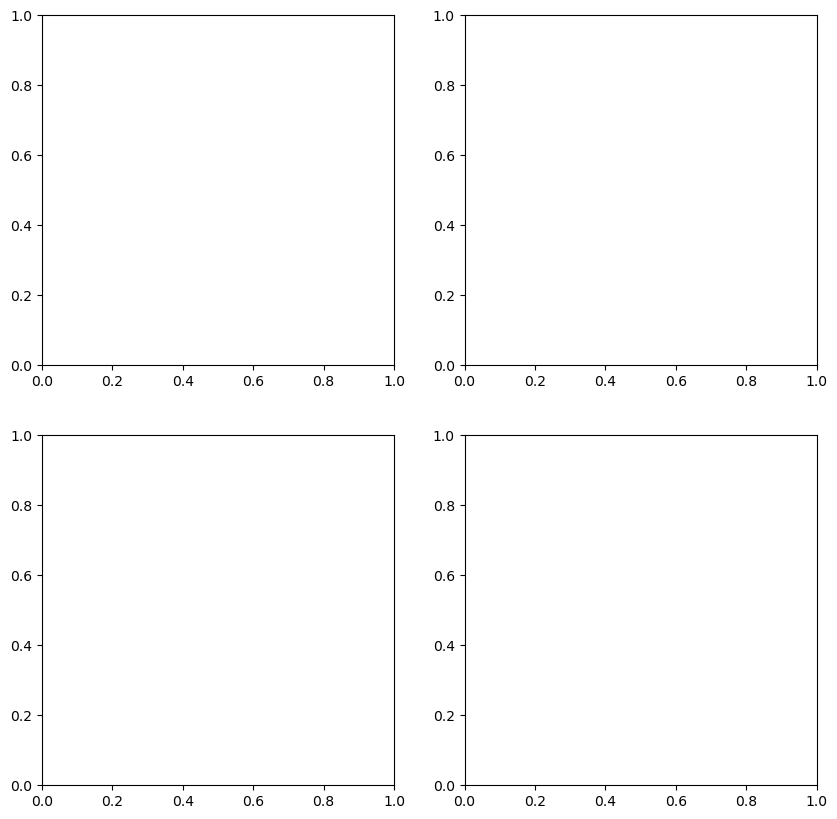

In [24]:
import seaborn as sns
fig, axs = plt.subplots(2,2)

fig.set_size_inches(10,10)

sns.kdeplot(x=train_ab['0_shift_a'], y=train_ab['1_shift_a'], ax=axs[0,0], cmap="coolwarm")

stat = np.round(scipy.stats.spearmanr(train_ab.dropna()['0_shift_a'], train_ab.dropna()['1_shift_a']).statistic, 2)
p_val = np.round(scipy.stats.spearmanr(train_ab.dropna()['0_shift_a'], train_ab.dropna()['1_shift_a']).pvalue, 2)

axs[0,0].set_title(f'Spearman R is {stat} with p value {p_val}')
axs[0,0].set_ylabel('$a(t+1)$')
axs[0,0].set_xlabel('$a(t)$')

sns.kdeplot(x=train_ab['0_shift_a'], y=train_ab['1_shift_b'], ax=axs[0,1], cmap="coolwarm")

stat = np.round(scipy.stats.spearmanr(train_ab.dropna()['0_shift_a'], train_ab.dropna()['1_shift_b']).statistic, 2)
p_val = np.round(scipy.stats.spearmanr(train_ab.dropna()['0_shift_a'], train_ab.dropna()['1_shift_b']).pvalue, 2)

axs[0,1].set_title(f'Spearman R is {stat} with p value {p_val}')
axs[0,1].set_ylabel('$b(t+1)$')
axs[0,1].set_xlabel('$a(t)$')


sns.kdeplot(x=train_ab['0_shift_b'], y=train_ab['1_shift_a'], ax=axs[1,0], cmap="coolwarm")
,
stat = np.round(scipy.stats.spearmanr(train_ab.dropna()['0_shift_b'], train_ab.dropna()['1_shift_a']).statistic, 2)
p_val = np.round(scipy.stats.spearmanr(train_ab.dropna()['0_shift_b'], train_ab.dropna()['1_shift_a']).pvalue, 2)

axs[1,0].set_title(f'Spearman R is {stat} with p value {p_val}')
axs[1,0].set_ylabel('$a(t+1)$')
axs[1,0].set_xlabel('$b(t)$')


sns.kdeplot(x=train_ab['0_shift_b'], y=train_ab['1_shift_b'], ax=axs[1,1], cmap="coolwarm")

stat = np.round(scipy.stats.spearmanr(train_ab.dropna()['0_shift_b'], train_ab.dropna()['1_shift_b']).statistic, 2)
p_val = np.round(scipy.stats.spearmanr(train_ab.dropna()['0_shift_b'], train_ab.dropna()['1_shift_b']).pvalue, 2)

axs[1,1].set_title(f'Spearman R is {stat} with p value {p_val}')
axs[1,1].set_ylabel('$b(t+1)$')
axs[1,1].set_xlabel('$b(t)$')

axs[0,0].set_xlim(-5,5)
axs[0,0].set_ylim(-5,5)

axs[0,1].set_xlim(-5,5)
axs[0,1].set_ylim(-3,3)


axs[1,0].set_xlim(-3,3)
axs[1,0].set_ylim(-5,5)

axs[1,1].set_xlim(-3,3)
axs[1,1].set_ylim(-3,3)


#plt.savefig('Parameter_Distributions.pdf', bbox_inches = 'tight')


In [25]:
features = [f'{i}_shift_a' for i in range(5)] + [f'{i}_shift_b' for i in range(5)]
targets = ['5_shift_a', '5_shift_b']

In [26]:
import sklearn.linear_model

In [27]:
lr = sklearn.linear_model.Lasso(alpha=0.0001)
train_ab_no_nans = train_ab.dropna()
test_ab_no_nans = test_ab.dropna()




lr.fit(train_ab_no_nans[features], train_ab_no_nans[targets[0]])
print(lr.score(train_ab_no_nans[features], train_ab_no_nans[targets[0]]))
print(lr.score(test_ab_no_nans[features], test_ab_no_nans[targets[0]]))

lr.fit(train_ab_no_nans[features], train_ab_no_nans[targets[1]])
print(lr.score(train_ab_no_nans[features], train_ab_no_nans[targets[1]]))
print(lr.score(test_ab_no_nans[features], test_ab_no_nans[targets[1]]))

0.0
-0.00031353522286559077
0.40963626210751325
0.34842441668811475


<>:2: SyntaxWarning: invalid escape sequence '\h'
<>:2: SyntaxWarning: invalid escape sequence '\h'
/var/folders/t5/hglcpfcd3px36gr5wgd_4mtm0000gn/T/ipykernel_2222/954122288.py:2: SyntaxWarning: invalid escape sequence '\h'
  plt.xlabel('$\hat{b}(t+1)$', fontsize=16)


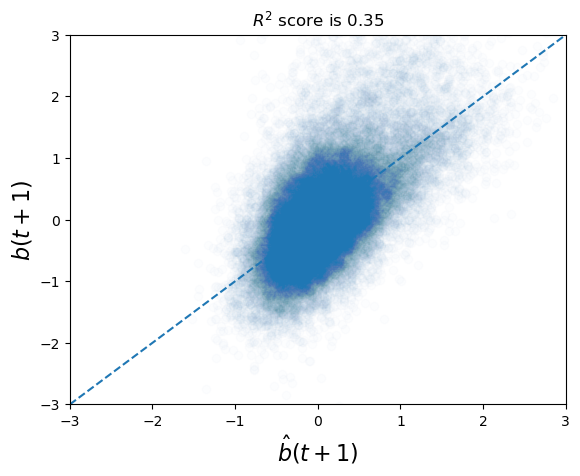

In [29]:
plt.scatter(lr.predict(test_ab_no_nans[features]), test_ab_no_nans[targets[1]], alpha=0.01)
plt.xlabel('$\hat{b}(t+1)$', fontsize=16)
plt.ylabel('$b(t+1)$', fontsize=16)

score = np.round(lr.score(test_ab_no_nans[features], test_ab_no_nans[targets[1]]), 2)
plt.title(f'$R^2$ score is {score}')
plt.xlim(-3,3)
plt.ylim(-3,3)
plt.plot([-3, 3], [-3, 3], '--')

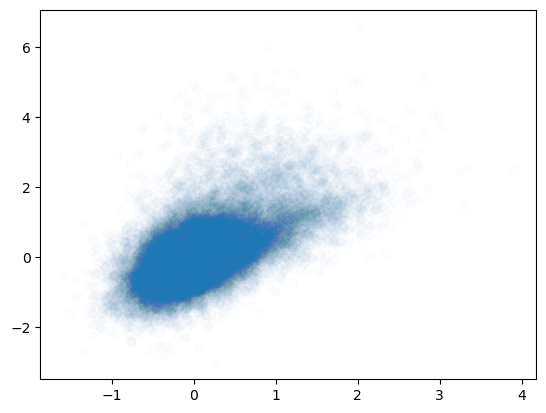

In [28]:
plt.scatter(lr.predict(test_ab_no_nans[features]), test_ab_no_nans[targets[1]], alpha=0.01)

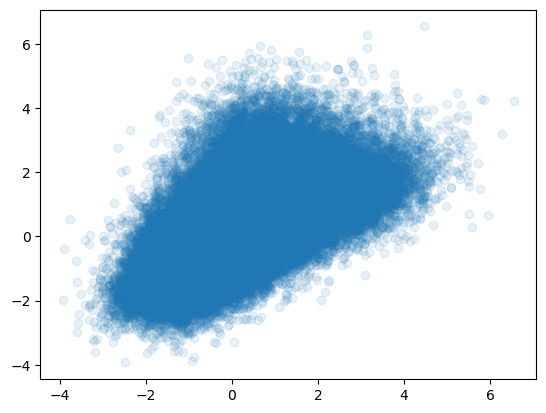

In [61]:
plt.scatter(train_b.dropna()['0_shift_b'], train_b.dropna()['1_shift_b'], alpha=0.1)

<Axes: xlabel='0_shift_b', ylabel='1_shift_b'>

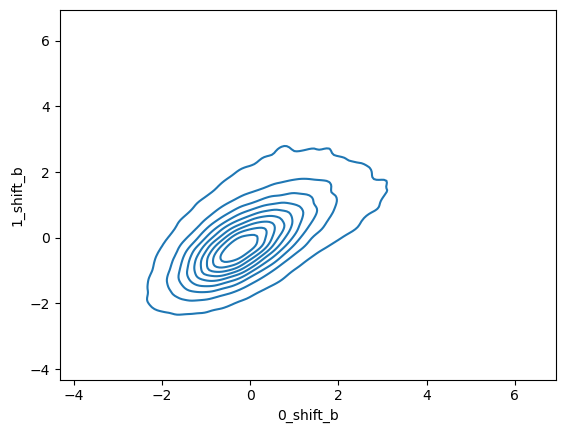

In [29]:
import seaborn

seaborn.kdeplot(x = train_b.dropna()['0_shift_b'], y = train_b.dropna()['1_shift_b'])

ValueError: Contour levels must be increasing

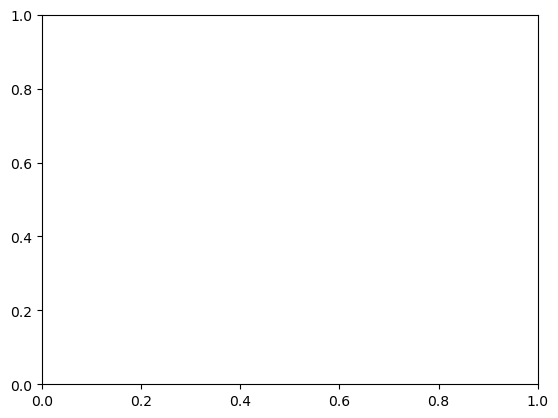

In [46]:
import seaborn

seaborn.kdeplot(x = train_a.dropna()['0_shift_a'], y = train_a.dropna()['1_shift_a'])

In [30]:
import xgboost

xgb_regressor = xgboost.XGBRegressor(n_estimators = 100, max_depth = 7, eta = 0.1)



xgb_regressor.fit(train_ab_no_nans[features], train_ab_no_nans[targets[1]])
print(xgb_regressor.score(train_ab_no_nans[features], train_ab_no_nans[targets[1]]))
print(xgb_regressor.score(test_ab_no_nans[features], test_ab_no_nans[targets[1]]))


0.44922346320874507
0.3434778858398039


In [31]:
import xgboost

xgb_regressor = xgboost.XGBRegressor(n_estimators = 100, max_depth = 6, eta = 0.1)



xgb_regressor.fit(train_ab_no_nans[features], train_ab_no_nans[targets[0]])
print(xgb_regressor.score(train_ab_no_nans[features], train_ab_no_nans[targets[0]]))
print(xgb_regressor.score(test_ab_no_nans[features], test_ab_no_nans[targets[0]]))


-2.220446049250313e-16
-0.00031353521667387696


In [412]:
import sklearn.ensemble

rf_regressor = sklearn.ensemble.RandomForestRegressor()

rf_regressor.fit(train_ab_no_nans[features], train_ab_no_nans[targets[1]])
print(rf_regressor.score(train_ab_no_nans[features], train_ab_no_nans[targets[1]]))
print(rf_regressor.score(test_ab_no_nans[features], test_ab_no_nans[targets[1]]))




KeyboardInterrupt



In [293]:
import sklearn.ensemble

xg_rf_regressor = xgboost.XGBRFRegressor()

xg_rf_regressor.fit(train_ab_no_nans[features], train_ab_no_nans[targets[1]])
print(xg_rf_regressor.score(train_ab_no_nans[features], train_ab_no_nans[targets[1]]))
print(xg_rf_regressor.score(test_ab_no_nans[features], test_ab_no_nans[targets[1]]))

0.379555091528492
0.3128028938708217


In [294]:
import sklearn.ensemble

xg_rf_regressor = xgboost.XGBRFRegressor()

xg_rf_regressor.fit(train_ab_no_nans[features], train_ab_no_nans[targets[0]])
print(xg_rf_regressor.score(train_ab_no_nans[features], train_ab_no_nans[targets[0]]))
print(xg_rf_regressor.score(test_ab_no_nans[features], test_ab_no_nans[targets[0]]))

0.01004401595615656
-0.0022368046305425437


In [441]:
import sklearn.ensemble

xg_regressor = xgboost.XGBRegressor(n_estimators = 100, max_depth = 6, eta=0.3, reg_lambda=1, objective="reg:pseudohubererror")

xg_regressor.fit(train_ab_no_nans[features], train_ab_no_nans[targets[0]])
print(xg_regressor.score(train_ab_no_nans[features], train_ab_no_nans[targets[0]]))
print(xg_regressor.score(test_ab_no_nans[features], test_ab_no_nans[targets[0]]))

0.06374009950462878
-0.014869028379373761


In [49]:
xgb_classifier = xgboost.XGBClassifier(n_estimators = 100, max_depth = 6)



xgb_classifier.fit(train_ab_no_nans[features], train_ab_no_nans[targets[0]]>0)
print(xgb_classifier.score(train_ab_no_nans[features], train_ab_no_nans[targets[0]]>0))
print(xgb_classifier.score(test_ab_no_nans[features], test_ab_no_nans[targets[0]]>0))


0.9728317047958964
0.9741456432277689


In [51]:
from sklearn.metrics  import classification_report

print(
    classification_report(
        y_pred=xgb_classifier.predict(test_ab_no_nans[features]),
        y_true=test_ab_no_nans[targets[0]]>0
    )
)

              precision    recall  f1-score   support

       False       0.99      0.98      0.98     23988
        True       0.95      0.96      0.95      9546

    accuracy                           0.97     33534
   macro avg       0.97      0.97      0.97     33534
weighted avg       0.97      0.97      0.97     33534



In [50]:
np.sum(test_ab_no_nans[targets[0]]>0)/len(test_ab_no_nans)

np.float64(0.2846663088208982)

In [315]:
from sklearn.linear_model import LogisticRegression

logistic_regressor = LogisticRegression()
logistic_regressor.fit(train_ab_no_nans[features], train_ab_no_nans[targets[0]]>0)
print(logistic_regressor.score(train_ab_no_nans[features], train_ab_no_nans[targets[0]]>0))
print(logistic_regressor.score(test_ab_no_nans[features], test_ab_no_nans[targets[0]]>0))


0.639459364577848
0.5724935885966482


In [372]:
probabilities = xgb_classifier.predict_proba(train_ab_no_nans[features])[:,1]

In [343]:
linear_regressor = sklearn.linear_model.LinearRegression()

linear_regressor.fit(xgb_classifier.predict_proba(train_ab_no_nans[features]), train_ab_no_nans[targets[0]])
print(linear_regressor.score(xgb_classifier.predict_proba(train_ab_no_nans[features]), train_ab_no_nans[targets[0]]))
print(linear_regressor.score(xgb_classifier.predict_proba(test_ab_no_nans[features]), test_ab_no_nans[targets[0]]))


0.0031287707012391808
-0.003363951454807612


In [383]:
np.std(train_ab_no_nans[targets[0]].values[probabilities<0.6])

np.float64(1.0025489835406345)

In [373]:
scipy.stats.spearmanr(probabilities, train_ab_no_nans[targets[0]])

SignificanceResult(statistic=np.float64(0.28861102084884216), pvalue=np.float64(0.0))

<Axes: ylabel='5_shift_a'>

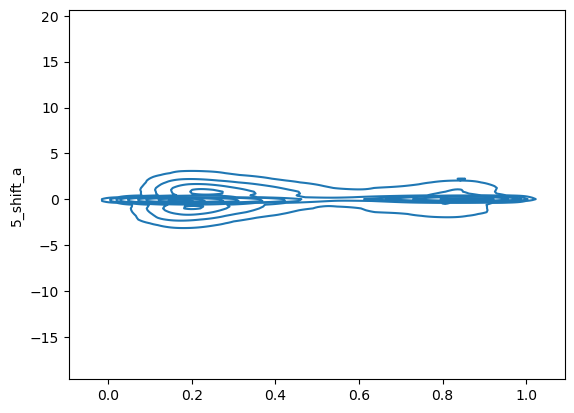

In [374]:
sns.kdeplot(x = probabilities, y = train_ab_no_nans[targets[0]])

0.9837249858779519
0.9927837749780614


Text(0, 0.5, 'True Positive Rate')

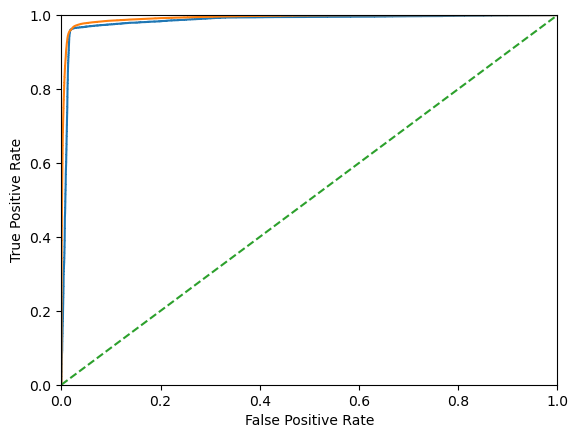

In [52]:
fpr, tpr, _ = sklearn.metrics.roc_curve(test_ab_no_nans[targets[0]]>0, xgb_classifier.predict_proba(test_ab_no_nans[features])[:,1])
plt.plot(fpr, tpr)
print(sklearn.metrics.auc(fpr, tpr))
fpr, tpr, _ = sklearn.metrics.roc_curve(train_ab_no_nans[targets[0]]>0, xgb_classifier.predict_proba(train_ab_no_nans[features])[:,1])
print(sklearn.metrics.auc(fpr, tpr))
plt.plot(fpr, tpr)
plt.plot([0, 1], [0, 1], ls = '--')
plt.xlim((0,1))
plt.ylim((0,1))
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')


0.951885762904924
0.988905929299455


Text(0, 0.5, 'Precision')

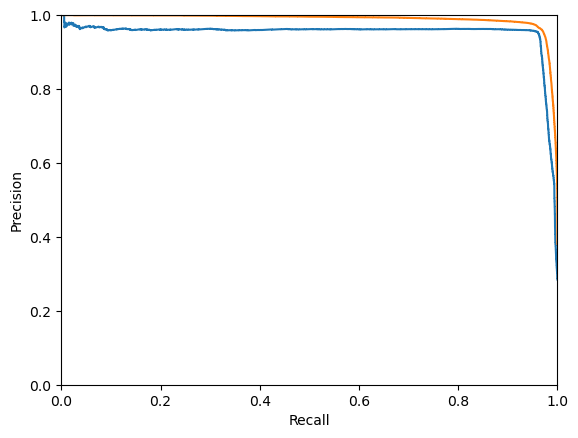

In [53]:
precision, recall, _ = sklearn.metrics.precision_recall_curve(test_ab_no_nans[targets[0]]>0, xgb_classifier.predict_proba(test_ab_no_nans[features])[:,1])
plt.plot(recall, precision)
print(sklearn.metrics.auc(recall, precision))
precision, recall, _ = sklearn.metrics.precision_recall_curve(train_ab_no_nans[targets[0]]>0, xgb_classifier.predict_proba(train_ab_no_nans[features])[:,1])
print(sklearn.metrics.auc(recall, precision))
plt.plot(recall, precision)
#plt.plot([0, 1], [0, 1], ls = '--')
plt.xlim((0,1))
plt.ylim((0,1))
plt.xlabel('Recall')
plt.ylabel('Precision')


0.008601209252247943
-0.016358707878123768


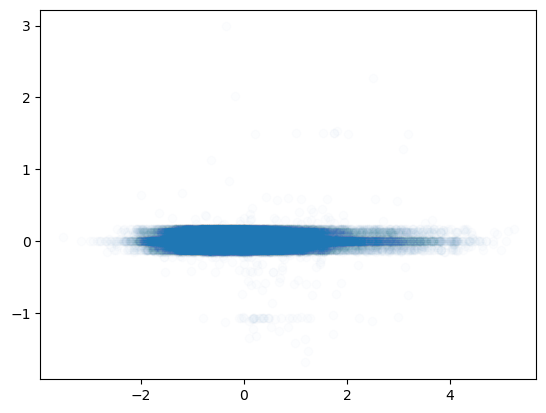

In [57]:
xgb_regressor = xgboost.XGBRegressor(n_estimators = 100, max_depth = 7, objective='reg:absoluteerror')



xgb_regressor.fit(train_ab_no_nans[features], train_ab_no_nans[targets[0]])
print(xgb_regressor.score(train_ab_no_nans[features], train_ab_no_nans[targets[0]]))
print(xgb_regressor.score(test_ab_no_nans[features], test_ab_no_nans[targets[0]]))

plt.scatter(test_ab_no_nans[targets[1]], xgb_regressor.predict(test_ab_no_nans[features]), alpha=0.01)

0.008601209252247943
-0.016358707878123768


(-0.2, 0.2)

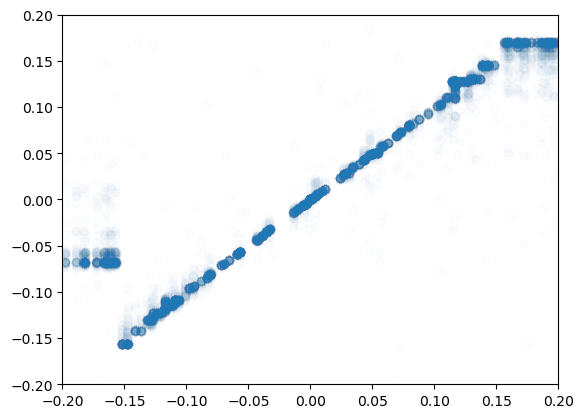

In [59]:
xgb_regressor = xgboost.XGBRegressor(n_estimators = 100, max_depth = 7, objective='reg:absoluteerror')



xgb_regressor.fit(train_ab_no_nans[features], train_ab_no_nans[targets[0]])
print(xgb_regressor.score(train_ab_no_nans[features], train_ab_no_nans[targets[0]]))
print(xgb_regressor.score(test_ab_no_nans[features], test_ab_no_nans[targets[0]]))

plt.scatter(test_ab_no_nans[targets[0]], xgb_regressor.predict(test_ab_no_nans[features]), alpha=0.01)
plt.xlim(-0.2,0.2)
plt.ylim(-0.2,0.2)


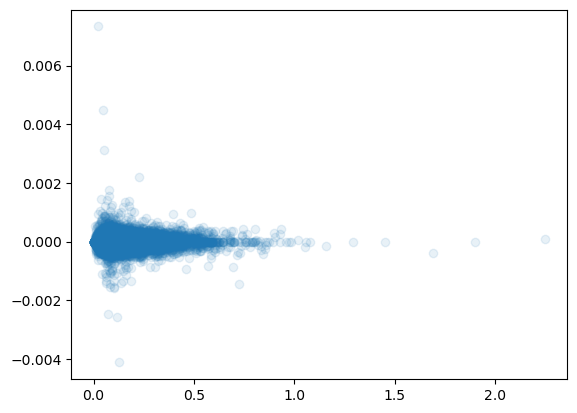

In [158]:
plt.scatter(train_ab['0_shift_b'], train_ab['1_shift_a'], alpha=0.1)


In [36]:
max(train_ab['0_shift_b'])

6.72664067975771

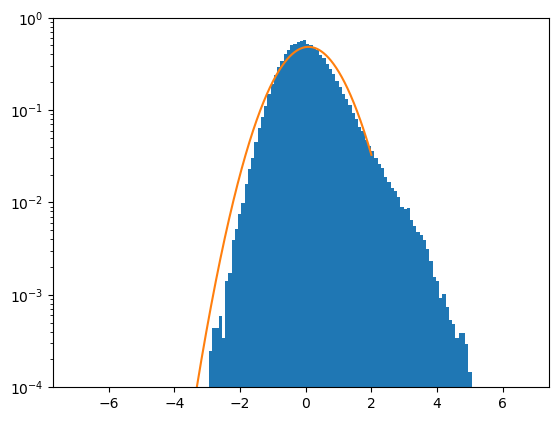

In [38]:
plt.hist(train_ab['0_shift_b'].dropna(), bins=100, density = True)
x = np.arange(-7, 2, 0.001)

mu = np.mean(train_ab['0_shift_b'])
std = np.std(train_ab['0_shift_b'])

y = 1./np.sqrt(2*np.pi*std**2) * np.exp(-(x - mu)**2/(2*std**2))

plt.yscale('log')
plt.ylim((10**-4, 10**0))
plt.plot(x,y)
plt.show()

In [160]:
scipy.stats.pearsonr(train_ab_no_nans['0_shift_b'], train_ab_no_nans['1_shift_a'])

PearsonRResult(statistic=np.float64(0.014196732284662578), pvalue=np.float64(9.114557599563118e-11))

In [163]:
train_ab_no_nans[features].corr()

,0_shift_a,1_shift_a,2_shift_a,3_shift_a,4_shift_a,0_shift_b,1_shift_b,2_shift_b,3_shift_b,4_shift_b
0_shift_a,1.000000,0.046113,0.020614,0.010958,0.014031,-0.113859,0.007869,0.007222,0.011892,0.009308
1_shift_a,0.046113,1.000000,0.046117,0.020679,0.010943,0.014197,-0.114375,0.007063,0.006369,0.011305
2_shift_a,0.020614,0.046117,1.000000,0.046096,0.020715,0.017060,0.014549,-0.114111,0.007415,0.006694
3_shift_a,0.010958,0.020679,0.046096,1.000000,0.045755,0.015433,0.016922,0.014281,-0.114297,0.007480
4_shift_a,0.014031,0.010943,0.020715,0.045755,1.000000,0.008695,0.015963,0.017534,0.014800,-0.113435
0_shift_b,-0.113859,0.014197,0.017060,0.015433,0.008695,1.000000,0.761045,0.667887,0.626776,0.611381
1_shift_b,0.007869,-0.114375,0.014549,0.016922,0.015963,0.761045,1.000000,0.760864,0.667716,0.626487
2_shift_b,0.007222,0.007063,-0.114111,0.014281,0.017534,0.667887,0.760864,1.000000,0.760475,0.667057
3_shift_b,0.011892,0.006369,0.007415,-0.114297,0.014800,0.626776,0.667716,0.760475,1.000000,0.760111
4_shift_b,0.009308,0.011305,0.006694,0.007480,-0.113435,0.611381,0.626487,0.667057,0.760111,1.000000


In [154]:
from sklearn.linear_model import HuberRegressor

huber = sklearn.linear_model.LinearRegression()
huber.fit(train_ab_no_nans[features], train_ab_no_nans[targets[0]])
print(huber.score(train_ab_no_nans[features], train_ab_no_nans[targets[0]]))
print(huber.score(test_ab_no_nans[features], test_ab_no_nans[targets[0]]))



0.0031470743801716994
-0.00033677607005211385


In [155]:
huber.coef_

array([ 2.48199814e-03,  1.00352084e-02,  9.46565274e-03,  1.88327439e-02,
        4.56495342e-02,  1.17267774e-05, -2.70897821e-05,  1.15067764e-05,
        1.29213895e-05,  1.84064344e-05])

In [102]:
train_ab_no_nans[targets[0]]>0

0         False
1         False
2          True
3          True
4         False
          ...  
212683    False
212684    False
212685    False
212686    False
212687    False
Name: 5_shift_a, Length: 208383, dtype: bool

In [40]:
import xgboost

xgb_regressor = xgboost.XGBRegressor()
train_a_no_nans = train_a.dropna()
test_a_no_nans = test_a.dropna()


xgb_regressor.fit(train_a_no_nans[['0 shift', '1 shift', '2 shift', '3 shift', '4 shift']], train_a_no_nans[['5 shift']])
print(xgb_regressor.score(train_a_no_nans[['0 shift', '1 shift', '2 shift', '3 shift', '4 shift']], train_a_no_nans[['5 shift']]))
print(xgb_regressor.score(test_a_no_nans[['0 shift', '1 shift', '2 shift', '3 shift', '4 shift']], test_a_no_nans[['5 shift']]))


KeyError: "None of [Index(['0 shift', '1 shift', '2 shift', '3 shift', '4 shift'], dtype='object')] are in the [columns]"

In [ ]:
one_shifted = a_params_train_df.shift(-1)
one_shifted.columns = [f'{col_name}_shift1' for col_name in a_params_train_df.columns]
one_shifted = pd.DataFrame(one_shifted.values.flatten())

two_shifted = a_params_train_df.shift(-2)
two_shifted.columns = [f'{col_name}_shift2' for col_name in a_params_train_df.columns]
two_shifted = pd.DataFrame(two_shifted.values.flatten())

three_shifted = a_params_train_df.shift(-3)
three_shifted.columns = [f'{col_name}_shift3' for col_name in a_params_train_df.columns]
three_shifted = pd.DataFrame(three_shifted.values.flatten())

four_shifted = a_params_train_df.shift(-4)
four_shifted.columns = [f'{col_name}_shift4' for col_name in a_params_train_df.columns]
four_shifted = pd.DataFrame(four_shifted.values.flatten())

five_shifted = a_params_train_df.shift(-5)
five_shifted.columns = [f'{col_name}_shift5' for col_name in a_params_train_df.columns]
five_shifted = pd.DataFrame(five_shifted.values.flatten())

collapsed_df = pd.DataFrame(a_params_train_df.values.flatten())

train_a = pd.concat([collapsed_df, one_shifted, two_shifted, three_shifted, four_shifted, five_shifted], axis=1)



one_shifted = a_params_test_df.shift(-1)
one_shifted.columns = [f'{col_name}_shift1' for col_name in a_params_test_df.columns]
one_shifted = pd.DataFrame(one_shifted.values.flatten())

two_shifted = a_params_test_df.shift(-2)
two_shifted.columns = [f'{col_name}_shift2' for col_name in a_params_test_df.columns]
two_shifted = pd.DataFrame(two_shifted.values.flatten())

three_shifted = a_params_test_df.shift(-3)
three_shifted.columns = [f'{col_name}_shift3' for col_name in a_params_test_df.columns]
three_shifted = pd.DataFrame(three_shifted.values.flatten())

four_shifted = a_params_test_df.shift(-4)
four_shifted.columns = [f'{col_name}_shift4' for col_name in a_params_test_df.columns]
four_shifted = pd.DataFrame(four_shifted.values.flatten())

five_shifted = a_params_test_df.shift(-5)
five_shifted.columns = [f'{col_name}_shift5' for col_name in a_params_test_df.columns]
five_shifted = pd.DataFrame(five_shifted.values.flatten())

collapsed_df = pd.DataFrame(a_params_test_df.values.flatten())

test_a = pd.concat([collapsed_df, one_shifted, two_shifted, three_shifted, four_shifted, five_shifted], axis=1)